In [1]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from cycler import cycler



default_cycler = (cycler(color=['0.3', '0.5', '0.7', '0.5']) +
                  cycler(linestyle=['-', '--', ':', '-.']) + 
                  cycler(marker=['o', 'v', 'd', 'p']))

color=['0.3', '0.5', '0.7', '0.5']
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

plt.rc('axes', prop_cycle=default_cycler)
plt.rc('font', size=20)

In [2]:
# =============================================================================
#  APPLY THEME  --  Beamer "Madrid" look. Re-run any time to refresh styling.
# =============================================================================
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="01-Introduction-To-Causal-Inference.ipynb",
)
import course_helpers as chh

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 8 cell(s):
 cell_index   slide_id                                  tags
         10  slide-6-0 slide_hide_prompt, slide_remove_input
         14  slide-6-3 slide_hide_prompt, slide_remove_input
         20  slide-6-9 slide_hide_prompt, slide_remove_input
         22 slide-6-10 slide_hide_prompt, slide_remove_input
         29  slide-7-1 slide_hide_prompt, slide_remove_input
         32  slide-7-3 slide_hide_prompt, slide_remove_input
         35  slide-8-1 slide_hide_prompt, slide_remove_input
         41  slide-8-5 slide_hide_prompt, slide_remove_input


In [3]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

<div class="beamer-meta" data-author="Robert Pettis" data-date="Fall 2026"></div>

# Introduction to Causal Inference

### Causal Machine Learning

<br>

**Robert Pettis**
Fall 2026

## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Lost?</span> <span style="color:#2a2a2a; font-size:1.06em;"><code>git status</code> is always safe and usually tells you what to do. The <b>Sync fork</b> button on GitHub does the pull for you.</span></div>

## What Is Causal Inference?

<div style="max-width:1000px; margin:.2em auto; font-family:inherit;">
<div style="font-size:1.18em; color:#2a2a2a; margin-bottom:14px;">Association <b style="color:#73000A;">&ne;</b> causation<span style="color:#8a6d6d;"> ... except when it is.</span></div>
<div style="max-width:600px; margin:0 0 16px;">
<div style="background:#f8e4e7; border:1.5px solid #73000A; border-radius:10px; padding:9px 16px; color:#2a2a2a; font-size:1.05em; margin-bottom:8px;">Wine tonight <b style="color:#73000A;">&rarr;</b> headache tomorrow</div>
<div style="background:#f8e4e7; border:1.5px solid #73000A; border-radius:10px; padding:9px 16px; color:#2a2a2a; font-size:1.05em;">No wine <b style="color:#73000A;">&rarr;</b> no headache</div>
</div>
<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:12px 18px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 13px; border-radius:8px; font-weight:700; font-size:1.05em;">Goal</span><div style="color:#2a2a2a; font-size:1.08em; margin-top:8px;">Infer causation from association, and understand when association does and does not imply causation.</div></div>
</div>

## Why We Do Causal Inference

- To understand <b style="color:#73000A;">cause and effect</b> relationships
- We want the impact of <b style="color:#73000A;">interventions</b>, not just associations

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">The question</span> <span style="color:#2a2a2a; font-size:1.06em;">What if...?</span></div>

###### What is Artificial Intelligence and Machine Learning?

<div style="max-width:1000px; margin:.3em auto; font-family:inherit; font-size:1.0em;">
<div style="background:#73000A; color:#fff; padding:8px 18px; font-weight:700; font-size:1.12em; border-radius:10px;">AI, ML, and what people call "AI"</div>
<div style="padding:12px 6px 4px;">
<div><b style="color:#73000A; font-size:1.1em;">Artificial Intelligence (AI)</b><br><span style="color:#2a2a2a;">Any technique that makes a computer act intelligently.</span></div>
<div style="margin:11px 0 0 2.2em; border-left:3px solid #cf9aa1; padding-left:.7em;"><b style="color:#73000A; font-size:1.1em;"><span style="font-size:1.15em;">↳</span> Machine Learning (ML)</b><br><span style="color:#2a2a2a;">Algorithms that learn patterns from data instead of being hand programmed.</span></div>
<div style="margin:11px 0 0 4.6em; border-left:3px solid #cf9aa1; padding-left:.7em;"><b style="color:#73000A; font-size:1.1em;"><span style="font-size:1.15em;">↳</span> Transformers</b><br><span style="color:#2a2a2a;">One ML architecture, unusually good at sequences like text.</span></div>
<div style="margin:11px 0 0 7em; border-left:3px solid #cf9aa1; padding-left:.7em;"><b style="color:#73000A; font-size:1.1em;"><span style="font-size:1.15em;">↳</span> Large Language Models (LLMs)</b> <span style="color:#73000A; font-style:italic; font-size:.9em;">what people call "AI"</span><br><span style="color:#2a2a2a;">ChatGPT, Claude, Gemini. Transformers trained on enormous amounts of text.</span></div>
</div>


## Machine Learning and Causal Inference

- Most causal questions are "what if" $\to$ ML is bad at those
- ML is superb at <b style="color:#73000A;">prediction</b>, inside fixed conditions
- It breaks the moment you change the inputs, which is what an intervention does

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Later</span> <span style="color:#2a2a2a; font-size:1.06em;">Reuse ML as flexible <i>models</i>, not prediction machines.</span></div>

## Association and Causation

<div style="line-height:2.2; font-size:1.05em;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Example</span> &nbsp;kids' toy stores, online marketplace, December<br><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Question</span> &nbsp;does cutting price raise units sold?<br><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Data</span> &nbsp;one row per store-week (size, sale flag, units sold)</div>

In [4]:
data = pd.read_csv("./data/xmas_sales.csv")
data.head(6)

,store,weeks_to_xmas,avg_week_sales,is_on_sale,weekly_amount_sold
0,1,3,12.98,1,219.60
1,1,2,12.98,1,184.70
2,1,1,12.98,1,145.75
3,1,0,12.98,0,102.45
4,2,3,19.92,0,103.22
5,2,2,19.92,0,53.73


### The Unit of Analysis

The **unit** is whatever you intervene on and measure.

- Could be a <b style="color:#73000A;">person</b> (effect of a product on a customer) or <b style="color:#73000A;">state/city/etc</b>
- Here it is a <b style="color:#73000A;">business</b> (effect of a sale on a store)

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Watch for it</span> <span style="color:#2a2a2a; font-size:1.06em;">Naming the unit fixes what one row of data is, and what "the effect" is even about.</span></div>

### The Treatment and the Outcome

- <b style="color:#73000A;">Treatment</b> $T_i$: the intervention whose effect you want (here <i>is\_on\_sale</i>; some write $D$)

<div style="text-align:center; margin:14px 0; font-family:Georgia,'Times New Roman',serif; font-size:22px;"><span style="font-style:italic;">T<sub>i</sub></span> = <span style="font-size:52px; font-weight:200; vertical-align:middle;">{</span> <span style="display:inline-block; vertical-align:middle; text-align:left; line-height:1.55;">1&nbsp;&nbsp;if unit&nbsp;<span style="font-style:italic;">i</span>&nbsp;received the treatment<br>0&nbsp;&nbsp;otherwise</span></div>

- <b style="color:#73000A;">Outcome</b> $Y_i$: here <i>weekly\_amount\_sold</i>
- Causal inference studies the effect of $T$ on $Y$

### The Fundamental Problem

- Never see the same unit both treated and untreated
- Raw gap: on-sale stores sell about 150 more


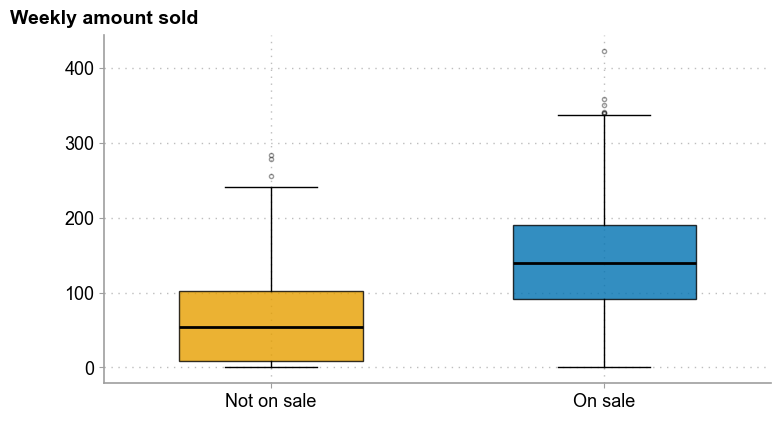

In [5]:
use_plotplainblind("mono")
fig, ax = plt.subplots(figsize=(8, 4.4))
g0 = data.query("is_on_sale == 0")["weekly_amount_sold"]
g1 = data.query("is_on_sale == 1")["weekly_amount_sold"]
bp = ax.boxplot([g0, g1], tick_labels=["Not on sale", "On sale"],
                patch_artist=True, widths=0.55,
                medianprops=dict(color="black", linewidth=2),
                flierprops=dict(marker="o", markersize=3, alpha=0.4))
for patch, col in zip(bp["boxes"], ["#E69F00", "#0072B2"]):
    patch.set_facecolor(col)
    patch.set_alpha(0.80)
    patch.set_edgecolor("black")
ax.set_xlabel("")
set_top_ylabel(ax, "Weekly amount sold", fontsize=14, fontweight="bold")
plt.tight_layout()

### What the Fundamental Problem Looks Like

Each unit has two potential outcomes. One gets realized (becomes <b style="color:#73000A;">factual</b>), one stays unknown (becomes <b style="color:#73000A;">counterfactual</b>).

### Causal Models

- A <b style="color:#73000A;">causal model</b> is a set of assignment mechanisms, written with $\leftarrow$ (not $=$)
- $u$ = the variables we do not model (<b style="color:#73000A;">exogenous</b>); the $f$'s map causes to effects

$$T \leftarrow f_t(u_t) \qquad\qquad Y \leftarrow f_y(T,\, u_y)$$

- $T$ has its own causes $u_t$; $Y$ is driven by $T$ plus other unmodeled causes $u_y$

### Why $\leftarrow$, not $=$

Causation is directional, so we cannot shuffle terms like algebra.

- With $=$: $\;Y = T + X\;$ is the same as $\;T = Y - X$
- But \"$T$ causes $Y$\" is <b style="color:#73000A;">not</b> the same as \"$Y$ causes $T$\"

### Pulling a Cause out of $u$: a Common Cause

Model business size explicitly instead of burying it in $u$:

$$\text{BusinessSize} \leftarrow f_s(u_s)$$
$$\text{is_on_sale} \leftarrow f_t(\text{BusinessSize},\, u_t)$$
$$\text{weekly_amount_sold} \leftarrow f_y(\text{is_on_sale},\, \text{BusinessSize},\, u_y)$$

- <b style="color:#73000A;">BusinessSize</b> causes the treatment (big stores discount more) <em>and</em> the outcome (big stores sell more)
- A variable that causes both is a <b style="color:#73000A;">common cause</b>: the source of bias

### The Same Model, in Econometrics Notation

If you come from stats or econ, you already write this:

$$\text{AmountSold}_i = \alpha + \beta_1 \text{IsOnSales}_i + \beta_2 \text{BusinessSize}_i + e_i$$

- Same structure as $f_y(\text{IsOnSales}, \text{BusinessSize}, u_y)$, with the function opened up
- The linear model <b style="color:#73000A;">adds</b> assumptions: a functional form (linear, additive), with $e$ playing the role of $u_y$
- It still says nothing about how IsOnSales and BusinessSize themselves came to be

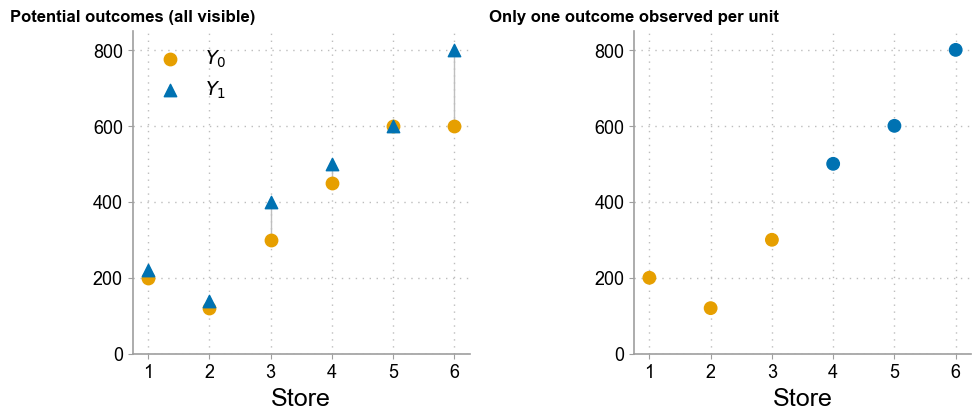

In [6]:
import matplotlib.pyplot as plt
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel

use_plotplainblind("mono")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.4))

# Left: All potential outcomes visible
stores = [1, 2, 3, 4, 5, 6]
y0_vals = [200, 120, 300, 450, 600, 600]
y1_vals = [220, 140, 400, 500, 600, 800]

ax1.scatter(stores, y0_vals, color="#E69F00", s=80, marker="o", label="$Y_0$", zorder=3)
ax1.scatter(stores, y1_vals, color="#0072B2", s=80, marker="^", label="$Y_1$", zorder=3)

# Draw individual treatment effects (vertical gaps)
for i, (y0, y1) in enumerate(zip(y0_vals, y1_vals), 1):
    ax1.plot([i, i], [y0, y1], color="gray", linewidth=1, alpha=0.5, zorder=1)

ax1.set_xlabel("Store")
set_top_ylabel(ax1, "Potential outcomes (all visible)", fontsize=12, fontweight="bold")
ax1.set_ylim(0, 850)
ax1.legend(loc="upper left", framealpha=0.9)
ax1.set_xticks(stores)

# Right: Only one outcome realized (the observed data)
t_vals = [0, 0, 0, 1, 1, 1]
y_obs = [y0_vals[i] if t_vals[i]==0 else y1_vals[i] for i in range(6)]
colors = ["#E69F00" if t==0 else "#0072B2" for t in t_vals]

ax2.scatter(stores, y_obs, color=colors, s=80, marker="o", zorder=3)
ax2.set_xlabel("Store")
set_top_ylabel(ax2, "Only one outcome observed per unit", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 850)
ax2.set_xticks(stores)

plt.tight_layout()

### Interventions

What would happen if the outcome Y if we were to force the treatment to be $t_0$?

$$T \leftarrow t_0$$

$$Y \leftarrow f_y(T,\, u_y)$$


**do(.) operator**
 - To reason on what would happen if you intervene on T, write $do(T=t_0)$



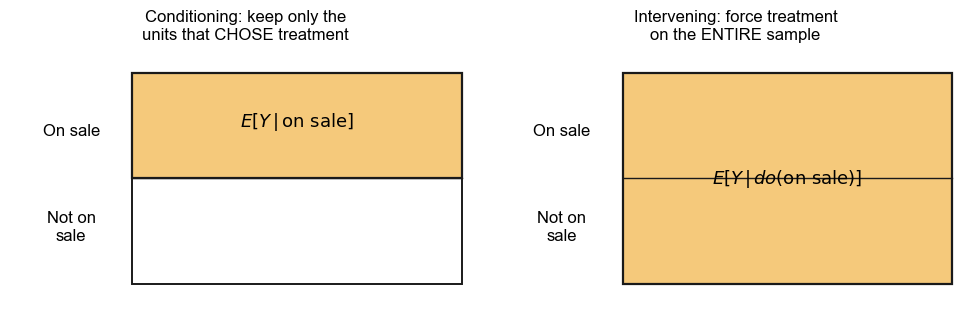

In [7]:
chh.fig_selection_vs_intervention()

### Individual Treatment Effect

$$\tau_i = Y_i \mid do(T{=}1) \;-\; Y_i \mid do(T{=}0)$$

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"> Writable, but only one of the two terms is ever observed.</div>

In our example:

$\tau_i = weekly\_amount\_sold_i \mid do(is\_on\_sale=1) - weekly\_amount\_sold_i \mid do(is\_on\_sale=0)$

### Potential Outcomes

- $Y_{ti} = Y_i \mid do(T_i = t)$: outcome if unit $i$ were set to $t$
- $Y_{1i}, Y_{0i}$: one factual, one counterfactual
- $\tau_i = Y_{1i} - Y_{0i}$

### Assumptions

Potential outcomes quietly lean on two assumptions:

- <b style="color:#73000A;">Consistency</b>: the treatment has no hidden versions, $Y_i(t) = Y_i$ when $T_i = t$
    - Breaks when a single "coupon" flag was really several dollar amounts lumped together
- <b style="color:#73000A;"> Stable unit of treatment value (SUTVA)</b>: one unit's treatment does not move another unit's outcome
    - Breaks with spillovers: vaccinate one person and their neighbours are safer too

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Why care</span> <span style="color:#2a2a2a; font-size:1.06em;">Both are assumptions, not facts, and usually cannot be tested in the data. Violations quietly bias the effect, and we meet them again with experiments and networks.</span></div>

### Causal Quantities of Interest

- Cannot get $\tau_i$, but can get averages
- <b style="color:#73000A;">ATE</b> $= E[\tau_i] = E[Y_1 - Y_0]$
  - Estimate: $\dfrac{}{}\sum_{i=0}^N(Y_{1i}-Y_{0i})$    **Can't do this though**
- <b style="color:#73000A;">ATT</b> $= E[Y_1 - Y_0 \mid T{=}1]$
- <b style="color:#73000A;">CATE</b> $= E[Y_1 - Y_0 \mid X{=}x]$ $\;\leftarrow$ our focus!

# Continuous Treatment

Replace the difference with a partial derivative:

$$\frac{\partial}{\partial t}E[Y_i]$$

### Causal Quantities: An Example

- Pretend we can see <b style="color:#73000A;">both</b> potential outcomes (six stores)
- Then it is trivial: ATE $= 65$, ATT $= 83.3$
- CATE $= 150$ a week before Christmas vs $22.5$ on Christmas week

In [8]:
pd.DataFrame(dict(
    i= [1,2,3,4,5,6],
    y0=[200,120,300, 450,600,600],
    y1=[220,140,400, 500,600,800],
    t= [0,0,0,1,1,1],
    x= [0,0,1,0,0,1],
)).assign(
    y = lambda d: (d["t"]*d["y1"] + (1-d["t"])*d["y0"]).astype(int),
    te=lambda d: d["y1"] - d["y0"]
)

,i,y0,y1,t,x,y,te
0,1,200,220,0,0,200,20
1,2,120,140,0,0,120,20
2,3,300,400,0,1,300,100
3,4,450,500,1,0,500,50
4,5,600,600,1,0,600,0
5,6,600,800,1,1,800,200


### Check Yourself: ATE, ATT, and CATE

<div style="border:2px dashed #73000A; border-radius:10px; background:#fdf4f5; padding:13px 18px; max-width:960px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">? Check yourself</span><div style="margin-top:9px; color:#2a2a2a; line-height:1.9;">The six stores show both potential outcomes. Match each quantity to its number.<br><b style="color:#73000A;">ATE</b> &nbsp;all six stores, average effect<br><b style="color:#73000A;">ATT</b> &nbsp;only stores that chose to run sales<br><b style="color:#73000A;">CATE</b> &nbsp;($x=0$) stores one week before Christmas only<br><b>Which is largest?</b></div></div>

### Back to Reality

- Real data: one outcome per unit, the other is missing
- Causal inference is a <b style="color:#73000A;">missing data problem</b>

In [9]:
pd.DataFrame(dict(
    i= [1,2,3,4,5,6],
    y0=[200,120,300, np.nan, np.nan, np.nan,],
    y1=[np.nan, np.nan, np.nan, 500,600,800],
    t= [0,0,0,1,1,1],
    x= [0,0,1,0,0,1],
)).assign(
    y = lambda d: np.where(d["t"]==1, d["y1"], d["y0"]).astype(int),
    te=lambda d: d["y1"] - d["y0"]
)

,i,y0,y1,t,x,y,te
0,1,200.0,NaN,0,0,200,NaN
1,2,120.0,NaN,0,0,120,NaN
2,3,300.0,NaN,0,1,300,NaN
3,4,NaN,500.0,1,0,500,NaN
4,5,NaN,600.0,1,0,600,NaN
5,6,NaN,800.0,1,1,800,NaN


### Naive Difference in Means: A Numeric Trap

With only one outcome per unit, the naive difference <b style="color:#73000A;">vastly overstates</b> the effect:

<table style="width:auto; margin:14px auto; border-collapse:collapse; font-size:1.08em;"><tr><th style="padding:5px 26px; border-bottom:2px solid #444; text-align:center;">Store</th><th style="padding:5px 26px; border-bottom:2px solid #444; text-align:center;"><i>Y</i> (observed)</th><th style="padding:5px 26px; border-bottom:2px solid #444; text-align:center;"><i>T</i></th></tr><tr><td style="padding:4px 26px; text-align:center;">1</td><td style="padding:4px 26px; text-align:center;">200</td><td style="padding:4px 26px; text-align:center;">0</td></tr><tr><td style="padding:4px 26px; text-align:center;">2</td><td style="padding:4px 26px; text-align:center;">120</td><td style="padding:4px 26px; text-align:center;">0</td></tr><tr><td style="padding:4px 26px; text-align:center;">3</td><td style="padding:4px 26px; text-align:center;">300</td><td style="padding:4px 26px; text-align:center;">0</td></tr><tr><td style="padding:4px 26px; text-align:center;">4</td><td style="padding:4px 26px; text-align:center;">500</td><td style="padding:4px 26px; text-align:center;">1</td></tr><tr><td style="padding:4px 26px; text-align:center;">5</td><td style="padding:4px 26px; text-align:center;">600</td><td style="padding:4px 26px; text-align:center;">1</td></tr><tr><td style="padding:4px 26px; text-align:center; border-bottom:2px solid #444;">6</td><td style="padding:4px 26px; text-align:center; border-bottom:2px solid #444;">800</td><td style="padding:4px 26px; text-align:center; border-bottom:2px solid #444;">1</td></tr></table>

Naive difference $= E[Y \mid T=1] - E[Y \mid T=0] = 633.3 - 206.7 = 426.7$

But the true ATE was $65$. The gap is the <b style="color:#73000A;">bias term</b>.

## Bias



$\underbrace{E[Y \mid T=1] - E[Y \mid T=0]}_{\text{Association}} = \underbrace{E[Y_1 - Y_0 \mid T=1]}_{\text{ATT}} + \underbrace{E[Y_0 \mid T=1] - E[Y_0 \mid T=0]}_{\text{BIAS}}$

- Kill the bias term and association becomes causation




In [10]:
# Now break it into ATT and Bias
# Recall from the potential outcomes table:
# i   y0   y1  t  x
# 0  200  220  0  0
# 1  120  140  0  0
# 2  300  400  0  1
# 3  450  500  1  0
# 4  600  600  1  0
# 5  600  800  1  1

import pandas as pd
import numpy as np

y0 = np.array([200, 120, 300, 450, 600, 600])
y1 = np.array([220, 140, 400, 500, 600, 800])
t = np.array([0, 0, 0, 1, 1, 1])

# ATT = E[Y1 - Y0 | T=1]
att = (y1[t==1] - y0[t==1]).mean()
print(f"ATT = E[Y_1 - Y_0 | T=1] = {att:.1f}")

# Bias = E[Y0 | T=1] - E[Y0 | T=0]
bias = y0[t==1].mean() - y0[t==0].mean()
print(f"Bias = E[Y_0 | T=1] - E[Y_0 | T=0] = {bias:.1f}")

# Observed difference
observed = y1[t==1].mean() - y0[t==0].mean()
print(f"Observed = E[Y | T=1] - E[Y | T=0] = {observed:.1f}")

# Verify: Observed = ATT + Bias
print(f"\nVerify: ATT + Bias = {att:.1f} + {bias:.1f} = {att + bias:.1f}")

ATT = E[Y_1 - Y_0 | T=1] = 83.3
Bias = E[Y_0 | T=1] - E[Y_0 | T=0] = 343.3
Observed = E[Y | T=1] - E[Y | T=0] = 426.7

Verify: ATT + Bias = 83.3 + 343.3 = 426.7


### BIAS!

- <b style="color:#73000A;">Bias</b> is why association $\neq$ causation

$$
\begin{aligned}
\underbrace{E[Y \mid T{=}1] - E[Y \mid T{=}0]}_{\text{Association}}
  &= E[Y_1 \mid T{=}1] - E[Y_0 \mid T{=}0] \\[16pt]
  &= E[Y_1 \mid T{=}1]
     \overbrace{-\, E[Y_0 \mid T{=}1] + E[Y_0 \mid T{=}1]}^{\pm\, E[Y_0 \mid T{=}1]}
     - E[Y_0 \mid T{=}0] \\[8pt]
  &= \underbrace{E[Y_1 - Y_0 \mid T{=}1]}_{\text{ATT}}
     + \underbrace{E[Y_0 \mid T{=}1] - E[Y_0 \mid T{=}0]}_{\text{BIAS}}
\end{aligned}
$$

- Add and subtract the treated group's *untreated* mean $E[Y_0 \mid T{=}1]$; the two cancel
- <b style="color:#73000A;">Kill the bias term and association becomes causation</b>


### Practical Example: A Glass of Wine a Day

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Example</span>

- Mediterranean countries: daily wine and long lives
- Wine drinkers and abstainers are <b style="color:#73000A;">not exchangeable</b>
- Italy and Spain also have generous healthcare and high HDI
- $E[Lifespan_0 \mid Wine = 1] > E[Lifespan_0 \mid Wine = 0]$: bias clouds the effect

### A Visual Guide to Bias

- Plot the outcome against a confounder (here, store size)
- Treated units already sit higher, before any sale runs
- The raw gap mixes the true effect with that head start

How does giving tablets to students help education? Blue dots didn’t receive the treatment, that is, the tablet.

<div style="text-align:center; margin-top:8px;">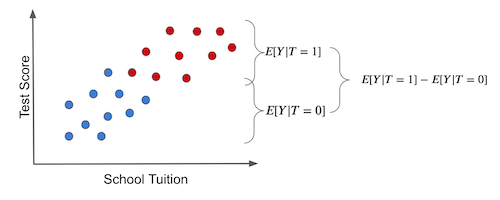<div style="font-size:.62em; color:#9a9a9a; margin-top:3px;"><a href="https://matheusfacure.github.io/python-causality-handbook/01-Introduction-To-Causality.html" style="color:#9a9a9a; text-decoration:none;">Source: Matheus Facure, <i>Causal Inference for the Brave and True</i>, Ch.&nbsp;1</a></div></div>

### A Visual Guide to Bias

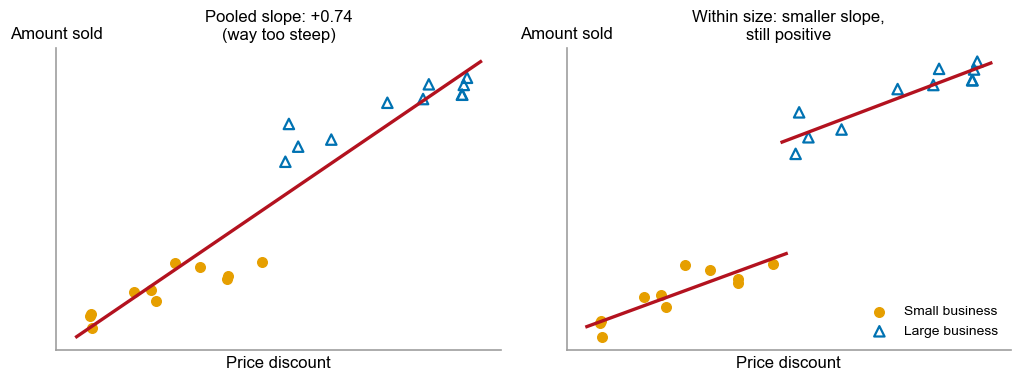

In [11]:
chh.fig_simpson_panels()

# Simpson's Paradox Worked Example

| Store Size | Not on Sale | On Sale | Within-Size Effect |
|------------|------------:|---------:|-------------------:|
| Small      | 50          | 60       | +10 |
| Large      | 200         | 220      | +20 |

<b style="color:#73000A;">Within each store size, sales increase with the promotion.</b>

| Pooled Comparison | Calculation | Average |
|-------------------|-------------|--------:|
| Not on Sale | (4×50 + 2×200)/6 | 100 |
| On Sale | (1×60 + 3×220)/4 | 180 |
| <b style="color:#73000A;">Pooled Effect</b> | 180 − 100 | <b style="color:#73000A;">+80</b> |

<b style="color:#73000A;">Why?</b> Large stores (which naturally sell more) are overrepresented in the promotion group.

### Seeing Bias with Potential Outcomes

- Add the counterfactuals (triangles): the individual effect is a <b style="color:#73000A;">small gap</b>
- The naive treated-vs-untreated gap is much larger. The difference is bias
- Look at $Y_0$ only: treated stores sit higher <b style="color:#73000A;">even without treatment</b>

### Bias, Seen Directly

Force everyone to skip the sale and look at $Y_0$ alone. The treated group still sits higher, and that gap is the bias.

<div style="text-align:center; margin-top:8px;">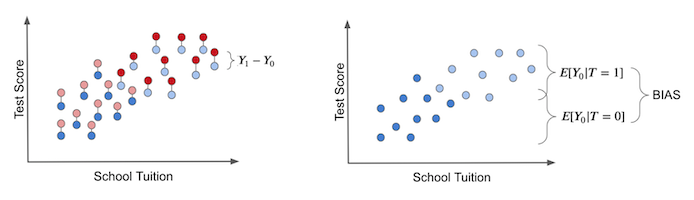<div style="font-size:.62em; color:#9a9a9a; margin-top:3px;"><a href="https://matheusfacure.github.io/python-causality-handbook/01-Introduction-To-Causality.html" style="color:#9a9a9a; text-decoration:none;">Source: Matheus Facure, <i>Causal Inference for the Brave and True</i>, Ch.&nbsp;1</a></div></div>

## The One Thing That Fixes It

- Bias is not a statistical problem. More data will not remove it
- It is an <b style="color:#73000A;">assumption</b> problem: you must justify comparability

## Identifying the Treatment Effect

- Need the bias term to vanish
- <b style="color:#73000A;">Independence</b>: $(Y_0, Y_1) \perp T \to$ groups exchangeable
- Then $E[Y_0 \mid T{=}1] = E[Y_0 \mid T{=}0]$, so bias $= 0$

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">The move</span> <span style="color:#2a2a2a; font-size:1.06em;">Assume treatment was assigned without regard to the outcomes, and the two groups become comparable.</span></div>

### Independence in Numbers

Suppose we could reset the world and assign treatment by a fair coin flip. Now treated and untreated would have the same distribution of $Y_0$.

<b style="color:#73000A;">With independence (hypothetical):</b>
- All six stores, randomized to treatment
- On average, the three treated would show the same $Y_0$ as the three untreated

$$E[Y_0 | T=1] = \frac{450 + 600 + 600}{3} = 550$$
$$E[Y_0 | T=0] = \frac{200 + 120 + 300}{3} = 206.67$$

Wait, that is still unequal. That is sampling noise. The point is: in expectation over repeated randomizations, the two would balance.

### Identification: A Two-Step Recipe

- <b style="color:#73000A;">Identification</b>: express the causal quantity in observable terms
- <b style="color:#73000A;">Estimation</b>: use data to estimate that expression
- If $E[Y_0|T=0] = E[Y_0|T=1]$, association <b style="color:#73000A;">is</b> causation
- Data alone is never enough: you need to know how the treatment came to be

### Independence in Plain Terms

Independence $(Y_0, Y_1) \perp T$ means the treatment is assigned without regard to the potential outcomes. Three ways to say the same thing:

1. <b style="color:#73000A;">Mathematically</b>: $E[Y_0 | T=1] = E[Y_0 | T=0]$
2. <b style="color:#73000A;">Practically</b>: treated and untreated units would have the same outcome distribution had none been treated
3. <b style="color:#73000A;">Visually</b>: if you plot $Y_0$ by group, the two groups overlap entirely with no shift

It is an assumption you argue for with domain knowledge, not something you test with the data.

### Identification with Randomization

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Setup</span>

Independence is the assumption we still owe a reason for. The cleanest reason: assign the treatment ourselves.

- Suppose we can <b style="color:#73000A;">randomize</b> who goes on sale
- We negotiate the right to force a store onto sale, and the marketplace covers the lost margin
- Now the sale flag is a <b style="color:#73000A;">coin flip</b>, not the store's choice

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Huge deal</span> <span style="color:#2a2a2a; font-size:1.06em;">A coin flip cannot depend on store size, timing, or anything else. Independence now holds by construction.</span></div>

### Randomization Annihilates Bias

With a coin flip, treated and untreated overlap across store size, so the whole gap is the effect:

$$E[Y \mid T{=}1] - E[Y \mid T{=}0] = \text{ATE}$$

<div style="text-align:center; margin-top:8px;">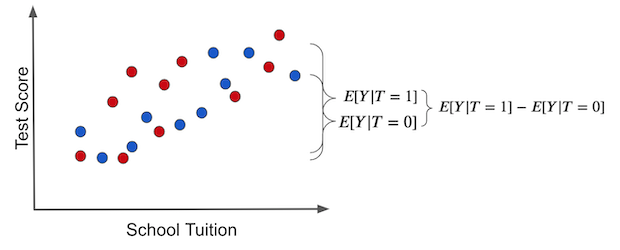<div style="font-size:.62em; color:#9a9a9a; margin-top:3px;"><a href="https://matheusfacure.github.io/python-causality-handbook/01-Introduction-To-Causality.html" style="color:#9a9a9a; text-decoration:none;">Source: Matheus Facure, <i>Causal Inference for the Brave and True</i>, Ch.&nbsp;1</a></div></div>

### No Bias in the Untreated

Force everyone to skip the sale and look at $Y_0$ alone: the groups line up, $E[Y_0 \mid T{=}0] = E[Y_0 \mid T{=}1]$.

<div style="text-align:center; margin-top:8px;">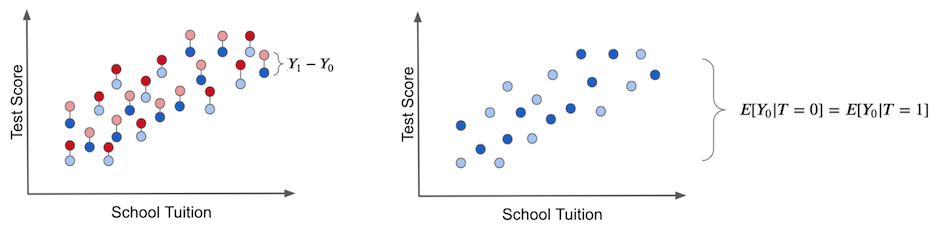<div style="font-size:.62em; color:#9a9a9a; margin-top:3px;"><a href="https://matheusfacure.github.io/python-causality-handbook/01-Introduction-To-Causality.html" style="color:#9a9a9a; text-decoration:none;">Source: Matheus Facure, <i>Causal Inference for the Brave and True</i>, Ch.&nbsp;1</a></div></div>

### Randomized vs Observational

- <b style="color:#73000A;">Randomized</b>: we assigned the treatment, or the assignment mechanism is fully known and nondeterministic
- <b style="color:#73000A;">Observational</b>: you see which treatment each unit got, but not how it was assigned

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">The catch</span> <span style="color:#2a2a2a; font-size:1.06em;">Almost all real data is observational. Every method after this earns, by argument, the independence that randomization would have handed us for free.</span></div>

### Check Yourself: Why Randomization Kills Bias

<div style="border:2px dashed #73000A; border-radius:10px; background:#fdf4f5; padding:13px 18px; max-width:960px; line-height:1.7;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">? Check yourself</span><div style="margin-top:9px; color:#2a2a2a;">Randomizing treatment, in sequence:<br><b>1.</b> Before: each unit has two potential outcomes waiting.<br><b>2.</b> A coin flip picks one to become factual.<br><b>3.</b> After: treated and untreated groups are balanced on $Y_0$.<br><br><b>Why is step 3 true?</b></div></div>

### Practical Example: An Incredible Membership Program

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Example</span>

- Retailer randomizes <b style="color:#73000A;">eligibility</b> for a paid membership program
- Members turn out far more profitable than control. Huge success?
- No: among the eligible, <b style="color:#73000A;">opting in was a choice</b>, not a coin flip
- The engaged customers self-selected: $E[Rev_0 \mid OptIn=1] > E[Rev_0 \mid OptIn=0]$

## Identification vs Estimation

Two separate steps in causal inference:

<b style="color:#73000A;">Identification</b>: express a causal quantity in terms of the observable data.

<b style="color:#73000A;">Estimation</b>: use data to compute that expression.

<div style="border-left:6px solid #73000A; background:#fbeef0; border-radius:8px; padding:11px 16px; margin-top:13px;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Watch out</span> <span style="color:#2a2a2a; font-size:1.06em;">A perfect identification with bad estimation, or good estimation of a badly identified quantity, both fail.</span></div>

### Further Reading

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Further reading</span>

- Pearl and Mackenzie, *The Book of Why*: the identification story of this course, told for a general reader
- Pearl, *Causality*: the graphical framework in full formality
- H&uuml;nermund and Bareinboim (2023), "Causal Inference and Data Fusion in Econometrics": the bridge to the econometrics you know

## Key Ideas

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Takeaways</span>

- Association $\neq$ causation because of <b style="color:#73000A;">bias</b>
- Write effects with <b style="color:#73000A;">potential outcomes</b>; only one seen per unit
- Targets: <b style="color:#73000A;">ATE, ATT, CATE</b>
- <b style="color:#73000A;">Randomization</b> removes bias; otherwise argue exchangeability

### Check Yourself: The Membership Program Trap

<div style="border:2px dashed #73000A; border-radius:10px; background:#fdf4f5; padding:13px 18px; max-width:960px; line-height:1.7;"><span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">? Check yourself</span><div style="margin-top:9px; color:#2a2a2a;">A retailer randomizes <b>eligibility</b> for a paid membership. Among the eligible, 30% opt in and are highly profitable; 70% opt out and are less profitable.<br><br><b>Do you have a causal effect of membership on profit?</b></div></div>